# Entropi, temperatur og Boltzmann-fordelingen

:::{admonition} Læringsmål
:class: note
Etter å ha arbeidet med dette kapitlet skal du kunne:

- forklare sammenhengen mellom multiplisitet og Boltzmanns entropi
- beregne multiplisiteten og entropien for enkle systemer
- beskrive total energi som en sum av bidrag fra besatte energinivåer
- bruke sannsynlighetsargumenter til å forklare likevekt og retningen til spontane prosesser
- skille mellom absolutt og relativ bredde i en sannsynlighetsfordeling
- forklare det statistiske grunnlaget for termodynamikkens andre lov
- forklare hvordan temperatur knytter sammen energi og entropi
- beskrive hvordan Boltzmann-fordelingen følger av energiutveksling med et stort varmereservoar
:::

Et egg blir knust, en kake blir bakt. Biler ruster og hus forfaller. Kroppene våre blir gamle og slitne. Hvorfor skjer disse prosessene helt av seg selv? Og hvorfor kan vi ikke hindre dem i å skje? Svaret på det ligger i fenomenet _entropi_.

Entropi er ett av de begrepene i kjemien som lett kan virke abstrakt og unnvikende. Det blir ofte knyttet til «uorden», men det ordet forklarer verken hvorfor varme strømmer fra varmt til kaldt, eller hvorfor en gass fyller beholderen den slippes fri i. Den statistiske tolkningen gir oss en mer presis forklaring: Vi må undersøke hvor mange mikroskopiske måter hver makroskopiske tilstand kan realiseres på.

I dette kapitlet tar vi den mikroskopiske veien inn i entropibegrepet. Den østerrikske fysikeren Ludwig Boltzmann viste på slutten av 1800-tallet at entropi har en dyp statistisk betydning: **Entropi er et mål på antall mikroskopiske måter et system kan realisere sin makroskopiske tilstand på.** Jo flere måter, desto høyere entropi og desto mer sannsynlig er tilstanden.

:::{admonition} Kapitlet i et nøtteskall
:class: note
Energien bestemmes av hvilke energinivåer partiklene befinner seg på, entropien forteller hvor mange mikrotilstander som gir samme makrotilstand, og temperaturen styrer hvilke energifordelinger som er sannsynlige.
:::

:::{admonition} Tenk over før du går videre
:class: tip
Hva forbinder du med entropi fra før? Prøv også å formulere hvorfor det er utilstrekkelig å si at entropi bare er «uorden».
:::


## Fra multiplisitet til entropi

Vi repeterer kort utgangspunktet fra [introduksjonen](https://andreasdh.github.io/Bifrost/docs/introduksjon.html): En **makrotilstand** beskriver systemet med noen få størrelser, mens en **mikrotilstand** angir den fullstendige tilstanden innenfor modellen vi bruker. Antallet mikrotilstander som er forenlige med en bestemt makrotilstand, kalles **multiplisiteten** og betegnes $\Omega$.

For et [isolert system](https://andreasdh.github.io/Bifrost/docs/introduksjon.html#system-og-omgivelser) med fast energi, volum og partikkeltall behandles de tilgjengelige mikrotilstandene som like sannsynlige. En makrotilstand med stor $\Omega$ kan da realiseres på flere måter og observeres oftere enn en makrotilstand med liten $\Omega$. Boltzmann knyttet denne opptellingen til entropien:

:::{admonition} Boltzmanns entropi
:class: important

$$S=k_\mathrm{B}\ln\Omega$$

Her er $k_\mathrm{B}=1{,}380\,649\times10^{-23}\ \mathrm{J\,K^{-1}}$ Boltzmanns konstant.
:::

Logaritmen gjør entropien additiv. For to uavhengige delsystemer er

$$\Omega_\mathrm{tot}=\Omega_A\Omega_B$$

Dermed er

$$S_\mathrm{tot}=k_\mathrm{B}\ln(\Omega_A\Omega_B)=S_A+S_B$$

Entropi er derfor ikke ganske enkelt «uorden». I denne sammenhengen er entropi et mål på hvor mange mikroskopiske muligheter som er forenlige med den makroskopiske tilstanden.

:::{admonition} Underveisoppgave
:class: tip
Et system kan realisere makrotilstand A på 10 måter og makrotilstand B på 1000 måter.

1. Hvilken makrotilstand har størst entropi?
2. Regn ut $S_B-S_A$ uttrykt ved $k_\mathrm{B}$.
3. Hvorfor er ikke entropiforskjellen proporsjonal med $1000-10$?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Makrotilstand B har størst entropi. Forskjellen er

$$S_B-S_A=k_\mathrm{B}\ln\!\left(\frac{1000}{10}\right)=k_\mathrm{B}\ln100\approx4{,}61k_\mathrm{B}$$

Entropien avhenger av logaritmen til multiplisiteten. Det er forholdet mellom antall muligheter, ikke differansen mellom dem, som bestemmer entropiforskjellen.
:::


## Et kjemisk eksempel: gass i to kamre

Tenk deg en beholder delt i to like store kamre, $A$ og $B$, forbundet med en ventil. Til å begynne med er all gassen i kammer $A$, og ventilen er lukket. Så åpner vi ventilen. Vi vet alle hva som skjer: gassen fyller hele beholderen. Men *hvorfor* skjer det helt av seg selv, og hvorfor ser vi aldri det motsatte: at gassen spontant trekker seg tilbake til $A$?

For en ideell gass beveger molekylene seg uavhengig av hverandre, og når de to kamrene er like store, er hvert molekyl til enhver tid like sannsynlig i $A$ som i $B$. Man kan si at hvert molekyl er som et myntkast. Kron $=$ kammer $A$, mynt $=$ kammer $B$.

![Fri ekspansjon av en gass mellom to kamre](bilder/gass_mikro_makro.svg)

En sannsynlighetsfordeling for systemet kan se slik ut:

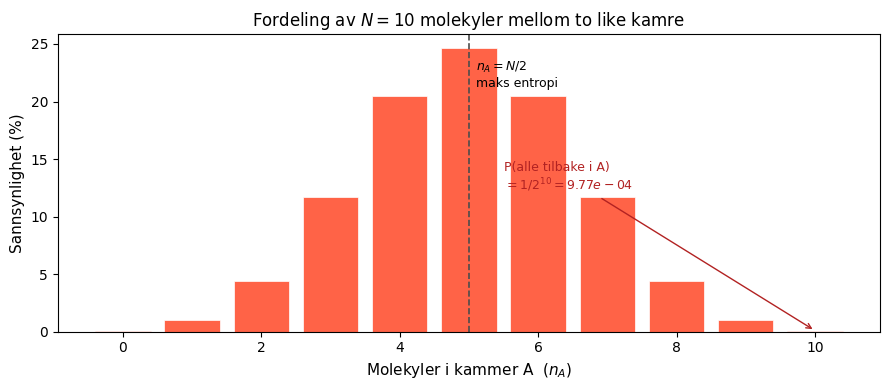

In [1]:
from math import comb
import numpy as np
import matplotlib.pyplot as plt

def omega_gass(N, nA):
    """Antall mikrotilstander for makrotilstanden 'nA molekyler i kammer A'."""
    return comb(N, nA)

def sannsynlighet_gass(N):
    """Analytisk fordeling P(nA) = C(N, nA) / 2**N."""
    nA = np.arange(0, N + 1)
    O  = np.array([omega_gass(N, int(k)) for k in nA], dtype=float)
    return nA, O / O.sum()          # summen er nettopp 2**N

def plott_gassfordeling(N):
    nA, P = sannsynlighet_gass(N)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(nA, P * 100, color='tomato', edgecolor='white', linewidth=0.5)
    ax.axvline(N / 2, color='0.3', ls='--', lw=1.2)
    ax.text(N / 2 + 0.1, P.max() * 100 * 0.96,
            r'$n_A = N/2$' + '\nmaks entropi', fontsize=9, va='top')
    ax.annotate(f'P(alle tilbake i A)\n$= 1/2^{{{N}}} = {P[-1]:.2e}$',
                xy=(N, P[-1] * 100), xytext=(N * 0.55, P.max() * 100 * 0.5),
                fontsize=9, color='firebrick',
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=1))
    ax.set_xlabel(r'Molekyler i kammer A  ($n_A$)', fontsize=11)
    ax.set_ylabel('Sannsynlighet (%)', fontsize=11)
    ax.set_title(f'Fordeling av $N = {N}$ molekyler mellom to like kamre')
    plt.tight_layout()
    plt.show()

plott_gassfordeling(10)

Fordelingen topper seg der molekylene er jevnt fordelt ($n_A = N/2$), og faller bratt mot kantene. Tilstanden «alle molekyler i $A$» ($n_A = N$) er bare *én* av $2^N$ mikrotilstander. Allerede med $N = 10$ molekyler er sannsynligheten for at gassen spontant samler seg i $A$ igjen under **0,1 %**. Det er dette som gjør fri ekspansjon irreversibel — det er ikke en kraft som drar molekylene utover, men det er rett og slett mange flere muligheter for at det skal skje!

Toppen ved $n_A=N/2$ er systemets **likevektsområde**: Det er her multiplisiteten og entropien er størst. Likevekt betyr ikke at molekylene slutter å bevege seg, eller at $n_A$ blir stående nøyaktig på $N/2$. Systemet skifter hele tiden mikrotilstand, og $n_A$ varierer rundt den mest sannsynlige verdien.

Når $N$ øker, blir fordelingen bredere målt i antall molekyler, men smalere målt i forhold til systemets størrelse. Det er denne stadig mindre *relative bredden* som gjør likevekt forutsigbart i et makroskopisk system.

### Simulering: se det skje

Simuleringen nedenfor viser $N$ molekyler i en beholder med en ventil i midten. Molekylene starter i kammer $A$ med ventilen lukket. Åpne ventilen og se gassen spre seg. Histogrammet til høyre bygger seg opp over tid og viser den observerte fordelingen av $n_A$ (gule søyler), mens den grønne kurven er den teoretiske fordelingen. Med preset-knappene kan du skalere $N$ opp og se hvordan dette påvirker systemet.

In [2]:
from IPython.display import IFrame
import base64

with open("Simuleringer/gassimulering.html", "r", encoding="utf-8") as f:
    innhold = f.read()

encoded = base64.b64encode(innhold.encode("utf-8")).decode("utf-8")
IFrame(f"data:text/html;base64,{encoded}", width="100%", height=860)


:::{admonition} Underveisoppgave
:class: tip
Bruk simuleringen til å svare. Skriv gjerne ned observasjonene underveis. «Start på nytt»
nullstiller alt, og histogrammet tømmes også når du bytter $N$.

**A. Fri ekspansjon.** Velg $N = 20$. Før du åpner ventilen: hva er $n_A$, og hva er $\Omega$?
Åpne ventilen. Hvilken vei går molekylene først, og hva skjer med $n_A$ og $\Omega$ etter hvert?
Legger $n_A$ seg helt i ro på $N/2$?

**B. Sammenlign med teorien.** La den kjøre en stund. Hvor godt følger de blå søylene den
oransje kurven, og hvor ligger toppen? Kurven er $\Omega(n_A)/2^N$. Hvorfor er det nettopp den
fordelingen søylene skal nærme seg?

**C. Sjeldne hendelser.** Velg $N = 4$. Hvor ofte havner alle fire molekylene i $A$ samtidig?
Sammenlign med $1/2^4$. Regn så ut det samme for $N = 100$: hvor mange observasjoner måtte du
i snitt gjøre, og hvor lenge ville du holdt på med hundre observasjoner i sekundet?

**D. Oppskalering.** Gå fra $N = 4$ til $20$ til $100$. Blir fordelingen bredere eller smalere
målt i antall molekyler? Og målt mot hele aksen fra $0$ til $N$? Hva skjer med $\Omega_{maks}$?

**E. Andre lov.** For hvilke $N$ ser ekspansjonen ut som en lov, og for hvilke ser du tydelige
tilbakeslag? Hva sier det om termodynamikkens andre lov?
:::

:::{admonition} Løsningsforslag
:class: tip, dropdown

**A.** Med ventilen lukket er $n_A = 20$ og $\Omega = 1$. Det finnes bare én måte å ha alle
molekylene i $A$ på. Når ventilen åpnes, går nettostrømmen mot $B$, rett og slett fordi det
er tjue kandidater på venstre side og ingen på høyre. $n_A$ synker mot 10, og $\Omega$ vokser
til $\Omega_{maks} = 184\,756$. Men $n_A$ blir ikke liggende i ro. Den svinger et par molekyler
opp og ned rundt 10, med typisk størrelse $\sigma = \sqrt{N}/2 \approx 2{,}2$.

Legg merke til at ingenting i bevegelsesreglene endret seg. Hvert molekyl spretter som før.
Det som endret seg, er hvor mange mikrotilstander makrotilstanden har.

**B.** Søylene legger seg på kurven, med toppen på $n_A = N/2 = 10$. Når ventilen er åpen og
kamrene er like store, er hvert molekyl like sannsynlig i $A$ som i $B$. Hver mikrotilstand
har da sannsynlighet $2^{-N}$, og makrotilstanden $n_A$ rommer $\Omega(n_A) = \binom{N}{n_A}$
av dem. Sannsynligheten for makrotilstanden blir derfor $\binom{N}{n_A}/2^N$, altså kurven.
Tilpasningen blir bedre jo lenger den får kjøre. To praktiske forbehold: statistikken starter
først når gassen har rukket å spre seg, og påfølgende målinger er korrelerte i tid, så det tar
lengre tid å konvergere enn $N$ uavhengige myntkast ville gjort.

**C.** For $N = 4$ er $\Omega_{tot} = 2^4 = 16$, og bare én mikrotilstand har alle i $A$. Altså
$P = 1/16 = 6{,}25\ \%$, omtrent én av seksten observasjoner. Det er den lille søyla helt til
høyre i histogrammet, og den er like høy som søyla helt til venstre, som er tilfellet der alle
er i $B$.

For $N = 100$ er $P = 1/2^{100} = 7{,}9 \cdot 10^{-31}$, altså i snitt $1{,}3 \cdot 10^{30}$
observasjoner. Med hundre i sekundet tar det $4 \cdot 10^{20}$ år, omtrent ti milliarder ganger
universets alder. Hendelsen er ikke forbudt. Den skjer bare aldri.

**D.** Bredden i antall molekyler vokser: $\sigma = \sqrt{N}/2$ gir 1, 2,2 og 5. Bredden målt mot
aksen krymper: $\sigma/\langle n_A \rangle = 1/\sqrt{N}$ gir 50 %, 22 % og 10 %. Det er derfor
toppen ser skarpere og skarpere ut selv om den faktisk blir bredere. $\Omega_{maks}$ vokser
eksplosivt: 6, deretter $184\,756$, deretter omtrent $10^{29}$. For ett mol er
$1/\sqrt{N} \approx 10^{-12}$, og svingningen er ikke målbar.

**E.** Med $N = 4$ ser du regelmessig at alt samler seg i det ene kammeret. Med $N = 20$ er store
avvik sjeldne, men $n_A = 15$ dukker opp innimellom. Med $N = 100$ ser du aldri noe langt fra 50.

Andre lov er altså ikke et forbud, men en sannsynlighetspåstand. Den har ingen unntak i praksis
fordi $N$ er astronomisk stor, ikke fordi bevegelseslikningene forbyr tilbakeslag. Hvert enkelt
molekyl er fullt reversibelt. Irreversibiliteten ligger i opptellingen.

Fra «alt i $A$» til fylt dobbeltvolum vokser $\Omega$ med en faktor $2^N$, så
$\Delta S = k_B \ln 2^N = N k_B \ln 2 = nR \ln 2$. Det er nøyaktig den makroskopiske
ekspansjonsentropien $\Delta S = nR \ln (V_2/V_1)$ med $V_2/V_1 = 2$.
:::

## Energi fordelt på to og tre nivåer

I gasseksemplet beskrev mikrotilstanden hvilket kammer hvert molekyl befant seg i. Nå ser vi på en annen enkel modell: _N_ partikler som kan befinne seg på noen få bestemte energinivåer. Vi begynner med et system med to nivåer. Det nederste nivået har energi $0$, mens det øverste har energi $\varepsilon$.

Tenk deg at vi har fire partikler. Dersom tre partikler er på det nederste nivået og én er på det øverste, kan vi beskrive fordelingen som

$$(n_0,n_1)=(3,1)$$

Her forteller $n_0$ hvor mange partikler som har energi $0$, og $n_1$ hvor mange som har energi $\varepsilon$. Til sammen er det fire partikler.

Totalenergien er i dette tilfellet

$$E=3\cdot0+1\cdot\varepsilon=\varepsilon$$

Fordelingen forteller bare hvor mange partikler som er på hvert nivå. Mikrotilstanden forteller i tillegg hvilken av de fire partiklene som er eksitert. Det finnes derfor fire forskjellige mikrotilstander som gir fordelingen $(3,1)$.

Antallet mikrotilstander som gir en bestemt fordeling, kalles multiplisiteten $\Omega$. For fordelingen $(3,1)$ er dermed $\Omega=4$.

Med to nivåer bestemmer energien fordelingen fullstendig. Hvis $n$ partikler er på det øverste nivået, er

$$E=n\varepsilon$$

Når vi legger til et tredje nivå med energi $2\varepsilon$, blir situasjonen litt mer interessant. Den samme totalenergien kan nå oppstå fra forskjellige fordelinger. Energien $E=2\varepsilon$ kan for eksempel lages ved at

- to partikler har energi $\varepsilon$
- én partikkel har energi $2\varepsilon$

Disse fordelingene har samme energi, men de kan ha ulik multiplisitet og dermed ulik entropi.

Simuleringen nedenfor lar deg utforske forskjellen mellom mikrotilstand, fordeling, energi og multiplisitet.

In [1]:
from IPython.display import HTML

with open("Simuleringer/niva-multiplisitet.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)


Øverste del av simuleringen viser én mikrotilstand. Tallene under viser fordelingen, energien og multiplisiteten. Diagrammet nederst viser hvor mange mikrotilstander som finnes ved de ulike energiene.

:::{admonition} Underveisoppgave
:class: tip

**A. To nivåer.** Velg to nivåer og $N=8$. Lag tilstander med henholdsvis $n=0$, $n=2$ og $n=4$ eksiterte partikler. Noter energien og multiplisiteten. Hvor er $\Omega$ størst? Trykk flere ganger på «Ny mikrotilstand (samme fordeling)». Hva endres, og hva er uendret?

**B. Likevekt og systemstørrelse.** Sammenlikn diagrammet for $N=4$, $N=8$ og $N=16$. Blir toppen bredere eller smalere målt i antall eksiterte partikler? Hva skjer med bredden målt i forhold til hele systemet?

**C. Tre nivåer.** Velg tre nivåer og $N=4$. Lag energien $E=2\varepsilon$. Finn de to mulige fordelingene $(n_0,n_1,n_2)$ og multiplisiteten til hver av dem. Kontroller at summen er lik $\Omega(E)$. Trykk deretter mange ganger på «Ny mikrotilstand (samme energi)». Hvilken fordeling ser du oftest, og hvorfor?

**D. Fra fast energi til fast temperatur.** Simuleringen viser $\Omega(E)$ for et isolert system, men sier ikke direkte hvilken energi som er mest sannsynlig når systemet er i kontakt med et varmereservoar ved temperaturen $T$. Hvilken ekstra vekting tror du må tas med?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown

**A.** For to nivåer er

$$\Omega(n)=\binom{N}{n}$$

Med $N=8$ får vi $\Omega(0)=1$, $\Omega(2)=28$ og $\Omega(4)=70$. Multiplisiteten er størst når partiklene er jevnest mulig fordelt mellom nivåene. Knappen for samme fordeling bytter hvilke partikler som er eksiterte. Mikrotilstanden endres, mens $n$, $E$ og $\Omega$ er uendret.

**B.** Den absolutte bredden i $n$ vokser som $\sqrt{N}/2$, men andelen $x=n/N$ får standardavviket $1/(2\sqrt{N})$. Fordelingen blir derfor smalere i forhold til systemets størrelse. For et makroskopisk system blir likevektsområdet ekstremt skarpt.

**C.** Ved $N=4$ og $E=2\varepsilon$ er de mulige fordelingene

$$ (n_0,n_1,n_2)=(2,2,0) $$

og

$$ (n_0,n_1,n_2)=(3,0,1) $$

Multiplisitetene er henholdsvis $4!/(2!2!)=6$ og $4!/(3!1!)=4$, slik at $\Omega(E)=6+4=10$. Når mikrotilstandene trekkes likt ved fast energi, kommer den første fordelingen i gjennomsnitt seks av ti ganger og den andre fire av ti ganger.

**D.** Ved en bestemt temperatur må multiplisiteten kombineres med en energivekt. Senere i kapitlet finner vi

$$P(E)\propto\Omega(E)e^{-E/k_\mathrm{B}T}$$

Multiplisiteten favoriserer energier med mange mikrotilstander, mens Boltzmann-faktoren demper høye energier. Temperaturen bestemmer balansen mellom disse hensynene.
:::


Vi kan beskrive den generelle sammenhengen mellom energinivåer og multiplisiteten som følger: Dersom $n_i$ er antallet partikler på energinivået $\varepsilon_i$, er det totale partikkeltallet

$$N=\sum_i n_i$$

Den totale energien er summen av antallet partikler på hvert energinivå og energien de har:

$$E=\sum_i n_i\varepsilon_i$$

For energinivåer som ikke er {ref}`degenererte <degenerasjon>`, er multiplisiteten til fordelingen

$$\Omega(\{n_i\})=\frac{N!}{\prod_i n_i!}$$

## Termodynamikkens andre lov som statistisk lov

De små systemene ovenfor viser at systemet stadig skifter mikrotilstand, men som oftest befinner seg i makrotilstandene med størst multiplisitet, altså de som kan realiseres av flest mikrotilstander. Det som dermed gjør termodynamikken *praktisk nyttig*, er at reelle systemer inneholder omtrent $10^{23}$ partikler. I et lite system kan energien av og til bevege seg «feil vei». I et makroskopisk system drukner slike variasjoner fullstendig i antallet mulige mikrotilstander.

For et isolert system formuleres [termodynamikkens andre lov](https://andreasdh.github.io/Bifrost/docs/grunnleggende_begreper.html#termodynamikkens-lover) som

$$\Delta S_\mathrm{tot}\geq0$$

for en spontan makroskopisk prosess. Den statistiske forklaringen er at makrotilstander med høy entropi svarer til langt flere mikrotilstander enn makrotilstander med lav entropi.

Når antallet partikler øker, vokser antallet mikrotilstander enormt, samtidig som sannsynlighetsfordelingen blir stadig smalere *relativt til systemets størrelse*. For den symmetriske tosidige modellen er middelverdien og standardavviket til antallet partikler i kammer $A$

$$\mu_{n_A}=\frac{N}{2}$$

$$\sigma_{n_A}=\frac{\sqrt{N}}{2}$$

For andelen $x=n_A/N$ er middelverdien $\mu_x=1/2$, mens standardavviket er

$$\sigma_x=\frac{1}{2\sqrt{N}}$$

Dersom bredden måles relativt til middelverdien, kanselleres faktoren $1/2$:

$$\frac{\sigma_x}{\mu_x}=\frac{1}{\sqrt{N}}$$


:::{admonition} Nyttige matematiske verktøy
:class: danger

Hva er $N$, $\mu$ og $\sigma$? Du kan lese mer om dette i [6.4 Normalfordeling](https://andreasdh.github.io/Bifrost/docs/matematikk/statistikk.html#normalfordelingen), resultatet ovenfor kan begrunnes i [6.5 Sentralgrenseteoremet](https://andreasdh.github.io/Bifrost/docs/matematikk/statistikk.html#sentralgrenseteoremet). Matematikken i detalj er ikke pensum, men et nyttig hjelpemiddel i forståelsen av statistikken vi presenterer her.
:::

For $N\approx10^{23}$ er dette omtrent $3\times10^{-12}$. Systemet skifter hele tiden mikrotilstand, men nesten alle mikrotilstandene vi observerer, tilhører makrotilstander svært nær entropimaksimum. En målbar, spontan reduksjon i total entropi er derfor ikke matematisk umulig, men så usannsynlig at den ikke observeres i et makroskopisk system.

:::{admonition} Viktig presisering
:class: note
Andre lov skyldes ikke en kraft som trekker systemet mot større entropi. Systemet utforsker tilgjengelige mikrotilstander, men et overveldende flertall av dem tilhører makrotilstander svært nær entropimaksimum.
:::

:::{admonition} Underveisoppgave
:class: tip
Forklar med egne ord hvorfor energi noen ganger kan overføres «feil vei» i et svært lite system, men ikke observeres å gjøre det som en vedvarende makroskopisk prosess.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
I et lite system er sannsynlighetsfordelingen relativt bred, og fluktuasjoner bort fra entropimaksimum kan derfor observeres. Når systemet blir makroskopisk, blir den relative fordelingen svært smal. Da finnes fluktuasjonene fortsatt på molekylnivå, men en vedvarende makroskopisk energioverføring i retningen som reduserer total entropi, er overveldende usannsynlig.
:::


### Energifordeling og termisk likevekt

I simuleringene ovenfor så vi at noen makrotilstander kan realiseres gjennom langt flere mikrotilstander enn andre. Systemet skifter hele tiden mikrotilstand, men observeres oftest i makrotilstandene med størst multiplisitet og entropi. 

Vi bruker nå det samme prinsippet på et system som består av to deler, A og B. Makrotilstanden beskriver denne gangen hvordan den totale energien er fordelt mellom delsystemene. Totalsystemet er isolert, men A og B kan utveksle energi. Hvis A har energien $U_A$, må resten av energien være i B:

$$U_B=U_\mathrm{tot}-U_A$$

For hver mulig energifordeling finnes det et bestemt antall mikrotilstander i A og et bestemt antall i B. En mikrotilstand for totalsystemet må angi mikrotilstanden til begge delsystemene. Multiplisitetene må derfor kombineres, og entropiene blir additive:

$$S_\mathrm{tot}=S_A+S_B$$

Den mest sannsynlige energifordelingen er den som gir flest mulige mikrotilstander for totalsystemet og dermed størst total entropi. Vi kan forstå maksimumspunktet ved å tenke oss at en liten energimengde flyttes fra B til A. Entropien til A vil da øke, mens entropien til B vil avta. Hvis økningen i $S_A$ er større enn reduksjonen i $S_B$, øker den totale entropien. Den opprinnelige energifordelingen kan da ikke ha vært den mest sannsynlige. Hvis reduksjonen i $S_B$ er størst, ville den totale entropien i stedet økt dersom energien ble flyttet den andre veien. Ved den mest sannsynlige energifordelingen må de to endringene akkurat oppveie hverandre. En liten omfordeling av energien kan da ikke øke den totale entropien ytterligere. Systemet er da i **termisk likevekt**.

Størrelsen

$$\left(\frac{\partial S}{\partial U}\right)_{V,N}$$

forteller hvor mye entropien endres når systemet får litt mer energi. Betingelsen for termisk likevekt er derfor

$$\left(\frac{\partial S_A}{\partial U_A}\right)_{V,N}=\left(\frac{\partial S_B}{\partial U_B}\right)_{V,N}$$

Termisk likevekt oppstår altså når en liten energimengde har den samme betydningen for entropien i begge delsystemene.

Likevekt betyr ikke at energien er låst i én bestemt fordeling. I et lite system vil energien fortsatt flyte mellom A og B. Systemet befinner seg likevel oftest nær fordelingen med størst total entropi. Når systemet blir større, blir disse variasjonene stadig mindre i forhold til den totale energien, og likevekten blir mer tydelig.

### Temperatur

Vi har nå kommet fram til en størrelse som har samme verdi i begge delsystemene ved termisk likevekt. Denne størrelsen beskriver hvor mye entropien endres når energien til systemet øker litt. På den absolutte temperaturskalaen defineres den som den inverse temperaturen, og dette gir oss dermed en definisjon av temperatur som er begrunnet med mikroskopiske argumenter om entropi:

:::{admonition} Temperatur
:class: important

$$\frac{1}{T}=\left(\frac{\partial S}{\partial U}\right)_{V,N}$$

:::

Temperatur er dermed et mål på sammenhengen mellom energi og entropi:

- Stor $\partial S/\partial U$ betyr at litt ekstra energi gir en stor økning i entropien. Da er temperaturen lav.
- Liten $\partial S/\partial U$ betyr at litt ekstra energi gir en mindre økning i entropien. Da er temperaturen høy.

Betingelsen for termisk likevekt kan derfor skrives som

$$T_A=T_B$$

:::{admonition} Termisk likevekt
:class: important

Termisk likevekt er den mest sannsynlige fordelingen av energien mellom delsystemer i kontakt. Ved denne fordelingen er den totale entropien maksimal og delsystemene har samme temperatur.

:::

:::{dropdown} Hvor kommer temperaturdefinisjonen fra?

La delsystemene A og B kunne omfordele energi, mens totalsystemets energi er konstant:

$$U_\mathrm{tot}=U_A+U_B$$

Hvis system A mottar en liten energimengde, må system B miste den samme energimengden:

$$dU_B=-dU_A$$

Endringen i den totale entropien er

$$dS_\mathrm{tot}=dS_A+dS_B$$

Ved konstant volum og partikkeltall kan entropiendringene skrives som

$$dS_A=\left(\frac{\partial S_A}{\partial U_A}\right)_{V,N}dU_A$$

$$dS_B=\left(\frac{\partial S_B}{\partial U_B}\right)_{V,N}dU_B$$

Når vi bruker at $dU_B=-dU_A$, får vi

$$dS_\mathrm{tot}=\left[\left(\frac{\partial S_A}{\partial U_A}\right)_{V,N}-\left(\frac{\partial S_B}{\partial U_B}\right)_{V,N}\right]dU_A$$

Ved termisk likevekt er den totale entropien maksimal. En liten omfordeling av energien kan da ikke øke entropien ytterligere. Derfor må

$$\left(\frac{\partial S_A}{\partial U_A}\right)_{V,N}=\left(\frac{\partial S_B}{\partial U_B}\right)_{V,N}$$

Vi har dermed funnet en størrelse som får samme verdi i begge delsystemene ved termisk likevekt. På den absolutte temperaturskalaen defineres denne størrelsen som den inverse temperaturen:

$$\frac{1}{T}=\left(\frac{\partial S}{\partial U}\right)_{V,N}$$

:::

Siden entropien er gitt ved

$$S=k_\mathrm{B}\ln\Omega$$

kan temperaturdefinisjonen også skrives som

$$\frac{1}{T}=k_\mathrm{B}\left(\frac{\partial\ln\Omega}{\partial U}\right)_{V,N}$$

Temperaturen forteller dermed hvor raskt antallet tilgjengelige mikrotilstander vokser når systemets energi øker.

Når ett av delsystemene er mye større enn det andre, vil en liten energiendring nesten ikke påvirke temperaturen til det store systemet. Det store systemet kan da behandles som et varmereservoar med tilnærmet konstant temperatur. Dette blir utgangspunktet for Boltzmann-fordelingen i neste avsnitt.

## Fra entropimaksimum til Boltzmann-fordelingen

Så langt har vi hovedsakelig betraktet isolerte systemer, der den totale energien er konstant. I laboratoriet er situasjonen ofte annerledes. Et relativt lite system kan stå i kontakt med store omgivelser, for eksempel en prøve i et stort vannbad.

Systemet kan da utveksle energi med omgivelsene. Omgivelsene er imidlertid så store at energien de avgir eller mottar, bare gir en svært liten endring i temperaturen. Vi kan derfor betrakte dem som et **varmereservoar** med tilnærmet konstant temperatur $T$.

Dette får en viktig konsekvens: Det lille systemet har ikke lenger én bestemt energi. Det kan befinne seg i mikrotilstander med forskjellige energier $E_i$. Men disse mikrotilstandene er ikke nødvendigvis like sannsynlige.

### Hvor sannsynlig er en mikrotilstand?

La systemet være i mikrotilstand $i$ med energi $E_i$. Systemet og reservoaret utgjør til sammen et isolert system med konstant total energi. Hvis systemet har energien $E_i$, må reservoaret derfor ha resten:

$$U_\mathrm{res}=U_\mathrm{tot}-E_i$$

Sannsynligheten for at systemet befinner seg i mikrotilstand $i$, avhenger av hvor mange mikrotilstander som samtidig er tilgjengelige for reservoaret.

Hvis det finnes mange mulige mikrotilstander for reservoaret når systemet er i tilstand $i$, finnes det også mange mikrotilstander for det samlede systemet som tilsvarer denne situasjonen. Tilstanden $i$ blir derfor relativt sannsynlig.

Vi kan uttrykke dette som

$$p_i\propto\Omega_\mathrm{res}(U_\mathrm{tot}-E_i)$$

der $\Omega_\mathrm{res}$ er antallet tilgjengelige mikrotilstander i reservoaret.

Her kommer energien til systemet inn: Hvis systemet har høyere energi, må reservoaret ha tilsvarende lavere energi. Det påvirker hvor mange mikrotilstander som er tilgjengelige for reservoaret.

For et stort reservoar viser det seg at denne sammenhengen gir

$$p_i\propto e^{-E_i/k_\mathrm{B}T}$$

Uttrykket $e^{-E_i/k_\mathrm{B}T}$ kalles **Boltzmann-faktoren**. Den gir den relative vekten til mikrotilstand $i$.

En mikrotilstand med lav energi får en større Boltzmann-faktor enn en mikrotilstand med høy energi. Tilstander med lav energi er derfor vanligvis mer sannsynlige.

:::{dropdown} Hvor kommer Boltzmann-faktoren fra?

Vi kan utlede Boltzmann-faktoren ved å kombinere sammenhengene mellom energi, entropi og antall mikrotilstander.

Når systemet befinner seg i mikrotilstand $i$ med energi $E_i$, har reservoaret energien

$$U_\mathrm{res}=U_\mathrm{tot}-E_i$$

Hvis systemet tar opp energien $E_i$, har reservoaret altså mistet den samme energimengden:

$$\Delta U_\mathrm{res}=-E_i$$

Fra temperaturdefinisjonen har vi

$$\frac{1}{T}=\left(\frac{\partial S}{\partial U}\right)_{V,N}$$

Denne deriverte forteller hvor mye entropien endres når energien endres litt. For en liten energiendring kan vi derfor skrive

$$\Delta S_\mathrm{res}\approx\left(\frac{\partial S_\mathrm{res}}{\partial U_\mathrm{res}}\right)_{V,N}\Delta U_\mathrm{res}$$

Siden reservoaret har temperaturen $T$, er

$$\left(\frac{\partial S_\mathrm{res}}{\partial U_\mathrm{res}}\right)_{V,N}=\frac{1}{T}$$

Reservoaret mister energien $E_i$, slik at

$$\Delta S_\mathrm{res}\approx\frac{1}{T}(-E_i)=-\frac{E_i}{T}$$

Dette betyr at reservoarets entropi blir litt lavere når det avgir energi til systemet.

Vi kan derfor skrive

$$S_\mathrm{res}\approx S_0-\frac{E_i}{T}$$

der $S_0$ er entropien reservoaret ville hatt dersom systemet ikke hadde tatt opp energien $E_i$.

Nå bruker vi Boltzmanns entropidefinisjon

$$S=k_\mathrm{B}\ln\Omega$$

Løser vi denne med hensyn på $\Omega$, får vi

$$\Omega=e^{S/k_\mathrm{B}}$$

Antallet tilgjengelige mikrotilstander i reservoaret blir dermed

$$\Omega_\mathrm{res}\approx e^{(S_0-E_i/T)/k_\mathrm{B}}=e^{S_0/k_\mathrm{B}}e^{-E_i/k_\mathrm{B}T}$$

Faktoren $e^{S_0/k_\mathrm{B}}$ er den samme for alle mikrotilstandene til systemet. Den påvirker derfor ikke hvilken mikrotilstand som er mer eller mindre sannsynlig.

Dermed står vi igjen med

$$\Omega_\mathrm{res}\propto e^{-E_i/k_\mathrm{B}T}$$

Siden $p_i\propto\Omega_\mathrm{res}$, får vi til slutt

$$p_i\propto e^{-E_i/k_\mathrm{B}T}$$

Dette er Boltzmann-faktoren.

:::

### Fra relative vekter til sannsynligheter

Boltzmann-faktoren gir foreløpig bare **relative sannsynligheter**. Den forteller for eksempel at en mikrotilstand med lav energi får større vekt enn en mikrotilstand med høy energi.

Men faktoren $e^{-E_i/k_\mathrm{B}T}$ er ikke i seg selv en sannsynlighet. Sannsynlighetene for alle mulige mikrotilstander må til sammen være lik 1:

$$\sum_i p_i=1$$

Vi må derfor gjøre de relative vektene om til faktiske sannsynligheter. Dette kalles å **normalisere** fordelingen, og er et [krav for sannsynlighetsfordelinger](https://andreasdh.github.io/Bifrost/docs/matematikk/statistikk.html#sannsynlighetsfordelinger).

Vi kan først skrive

$$p_i=C e^{-E_i/k_\mathrm{B}T}$$

der $C$ er en konstant som er den samme for alle mikrotilstandene.

Kravet $\sum_i p_i=1$ gir da

$$\sum_i C e^{-E_i/k_\mathrm{B}T}=1$$

Dermed må

$$C=\frac{1}{\sum_i e^{-E_i/k_\mathrm{B}T}}$$

Vi definerer summen

$$Q=\sum_i e^{-E_i/k_\mathrm{B}T}$$

Denne størrelsen kalles **partisjonsfunksjonen**. Den summerer Boltzmann-faktorene for alle mikrotilstandene og gjør det mulig å normalisere fordelingen.

Vi får dermed en sannsynlighetsfordeling som beskriver hvordan sannsynligheten for å finne et system i ulike energitilstander avhenger av energien til tilstanden og temperaturen. Dette kaller vi **Boltzmann-fordelingen**:

:::{admonition} Boltzmann-fordelingen
:class: important

$$p_i=\frac{e^{-E_i/k_\mathrm{B}T}}{Q}$$

der

$$Q=\sum_i e^{-E_i/k_\mathrm{B}T}$$

Partisjonsfunksjonen $Q$ sørger for at

$$\sum_i p_i=1$$

:::

### Utforsk Boltzmann-fordelingen

Vi kan nå se hvordan Boltzmann-fordelingen endres med temperaturen. I simuleringen under har systemet seks tillatte energinivåer med samme avstand $\Delta\varepsilon$ mellom nivåene:

$$E_n=n\Delta\varepsilon$$

Sannsynligheten for hvert nivå bestemmes av Boltzmann-fordelingen

$$p_n=\frac{e^{-E_n/k_\mathrm{B}T}}{Q}$$

Glidebryteren styrer forholdet $k_\mathrm{B}T/\Delta\varepsilon$. Dette sammenlikner den termiske energiskalaen $k_\mathrm{B}T$ med energiforskjellen mellom nivåene. Legg merke til at **energinivåene ikke flytter seg når temperaturen endres**. Det er sannsynligheten for å finne systemet på hvert nivå som endres. Søylene viser de normaliserte sannsynlighetene, slik at

$$\sum_n p_n=1$$

In [5]:

from IPython.display import HTML

with open("Simuleringer/boltzmann_sim.html", "r", encoding="utf-8") as f:
    html = f.read()

HTML(html)

:::{admonition} Prøv selv: Boltzmann-fordelingen
:class: tip

1. Sett $k_\mathrm{B}T/\Delta\varepsilon$ svært lavt. Hvilket nivå har størst sannsynlighet?
2. Øk temperaturen. Endres de tillatte energinivåene, eller bare sannsynlighetene?
3. Finn omtrent når det første eksiterte nivået får en tydelig sannsynlighet.
4. Forklar hvorfor elektroniske og vibrasjonelle eksitasjoner ofte er mindre sannsynlige enn rotasjonelle eksitasjoner ved romtemperatur.
5. Kontroller at sannsynlighetene alltid summerer til 1.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Ved lav temperatur dominerer grunntilstanden. Temperaturen skaper ikke nye energinivåer; den endrer Boltzmann-vektene. Eksiterte nivåer får merkbar sannsynlighet når energigapet ikke lenger er stort sammenliknet med $k_\mathrm{B}T$. Vibrasjonelle og elektroniske energigap er ofte større enn rotasjonelle energigap og krever derfor høyere temperatur før de bidrar tydelig.
:::


## Oppgaver

:::{admonition} Oppgave 1: Et to-nivåsystem
:class: tip
Åtte partikler kan være på energinivåene $0$ og $\varepsilon$. Tre av partiklene er eksiterte.

1. Finn totalenergien.
2. Beregn multiplisiteten.
3. Beregn entropien uttrykt ved $k_\mathrm{B}$.
4. Sammenlikn med makrotilstanden der fire partikler er eksiterte. Hvilken har størst entropi?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Totalenergien er $E=3\varepsilon$. Multiplisiteten er

$$\Omega(3)=\binom83=56$$

Entropien er $S=k_\mathrm{B}\ln56\approx4{,}03k_\mathrm{B}$. Når fire partikler er eksiterte, er $\Omega(4)=\binom84=70$. Denne makrotilstanden har derfor større entropi.
:::

:::{admonition} Oppgave 2: Samme energi, ulike fordelinger
:class: tip
Fire partikler kan være på nivåene $0$, $\varepsilon$ og $2\varepsilon$, og totalenergien er $E=2\varepsilon$.

1. Finn alle mulige fordelinger $(n_0,n_1,n_2)$.
2. Beregn multiplisiteten til hver fordeling.
3. Finn $\Omega(E)$.
4. Dersom alle mikrotilstander med denne energien er like sannsynlige, hva er sannsynligheten for hver av de to fordelingene?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Fordelingene er $(2,2,0)$ og $(3,0,1)$. Multiplisitetene er

$$\Omega(2,2,0)=\frac{4!}{2!2!}=6$$

$$\Omega(3,0,1)=\frac{4!}{3!1!}=4$$

Dermed er $\Omega(E)=10$. Sannsynlighetene er $6/10=0{,}60$ og $4/10=0{,}40$.
:::

:::{admonition} Oppgave 3: Temperatur og entropi
:class: tip
To systemer kan utveksle en liten energimengde, men totalsystemet er isolert.

1. Utled $dS_\mathrm{tot}=(1/T_A-1/T_B)dU_A$.
2. Bruk fortegnet til å avgjøre retningen på energiutvekslingen når $T_A>T_B$.
3. Vis at entropimaksimum krever $T_A=T_B$.
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Bruk $dS_A=dU_A/T_A$, $dS_B=dU_B/T_B$ og $dU_B=-dU_A$. Når $T_A>T_B$, er parentesen negativ, og $dS_\mathrm{tot}>0$ krever $dU_A<0$. Ved maksimum er den deriverte null, slik at $1/T_A=1/T_B$ og dermed $T_A=T_B$.
:::

:::{admonition} Oppgave 4: Boltzmann-forhold
:class: tip
To mikrotilstander har energiforskjellen $E_1-E_0=3k_\mathrm{B}T$.

1. Beregn $p_1/p_0$.
2. Hvordan endres forholdet dersom temperaturen dobles mens energigapet holdes fast?
:::

:::{admonition} Løsningsforslag
:class: tip dropdown
Ved den første temperaturen er $p_1/p_0=e^{-3}\approx0{,}0498$. Når temperaturen dobles, blir energigapet $1{,}5k_\mathrm{B}T_\mathrm{ny}$, og forholdet blir $e^{-1{,}5}\approx0{,}223$. Den eksiterte tilstanden får større relativ sannsynlighet.
:::


## Videre til partisjonsfunksjonen

Boltzmann-fordelingen forteller hvordan energien vekter mikrotilstandene, men normaliseringsfaktoren $Q$ er foreløpig uforklart. I neste kapittel ser vi at denne summen ikke bare sørger for at sannsynlighetene blir 1: Den knytter også mikrotilstandenes energier til målbare størrelser som indre energi, entropi og varmekapasitet.